# RetailIQ - Sales Forecasting

Builds a simple, explainable monthly sales forecast using Linear Regression (baseline) and Random Forest Regression (main model). Mirrors `analytics/forecasting.py`.

## 1. Load cleaned data & aggregate to monthly revenue

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/cleaned/retail_sales_cleaned.csv", parse_dates=["Date"])
monthly = df.set_index("Date").resample("MS")["Sales"].sum().reset_index().rename(columns={"Sales":"Revenue"})
monthly.head()

,Date,Revenue
0,2023-01-01,1.857357e+07
1,2023-02-01,1.619081e+07
2,2023-03-01,1.890397e+07
3,2023-04-01,1.650074e+07
4,2023-05-01,1.612771e+07


## 2. Feature engineering (trend, seasonality, lags)

In [2]:
monthly["month_index"] = np.arange(len(monthly))
monthly["month_of_year"] = monthly["Date"].dt.month
monthly["quarter"] = monthly["Date"].dt.quarter
monthly["lag_1"] = monthly["Revenue"].shift(1)
monthly["lag_2"] = monthly["Revenue"].shift(2)
monthly["lag_3"] = monthly["Revenue"].shift(3)
monthly = monthly.dropna().reset_index(drop=True)
monthly.tail()

,Date,Revenue,month_index,month_of_year,quarter,lag_1,lag_2,lag_3
28,2025-08-01,1.734812e+07,31,8,3,1.741806e+07,1.672575e+07,1.727561e+07
29,2025-09-01,1.631082e+07,32,9,3,1.734812e+07,1.741806e+07,1.672575e+07
30,2025-10-01,3.894836e+07,33,10,4,1.631082e+07,1.734812e+07,1.741806e+07
31,2025-11-01,4.093299e+07,34,11,4,3.894836e+07,1.631082e+07,1.734812e+07
32,2025-12-01,3.854615e+07,35,12,4,4.093299e+07,3.894836e+07,1.631082e+07


## 3. Train/test split (chronological - last 6 months held out)

In [3]:
FEATURES = ["month_index","month_of_year","quarter","lag_1","lag_2","lag_3"]
TARGET = "Revenue"
train, test = monthly.iloc[:-6], monthly.iloc[-6:]
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

## 4. Train Linear Regression (baseline) & Random Forest (main model)

In [4]:
lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42).fit(X_train, y_train)

lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.3f}")

evaluate(y_test, lr_preds, "Linear Regression")
evaluate(y_test, rf_preds, "Random Forest")

Linear Regression: MAE=4,906,862  RMSE=6,100,821  R2=0.706
Random Forest: MAE=602,000  RMSE=868,527  R2=0.994


## 5. Plot actual vs predicted (test period)

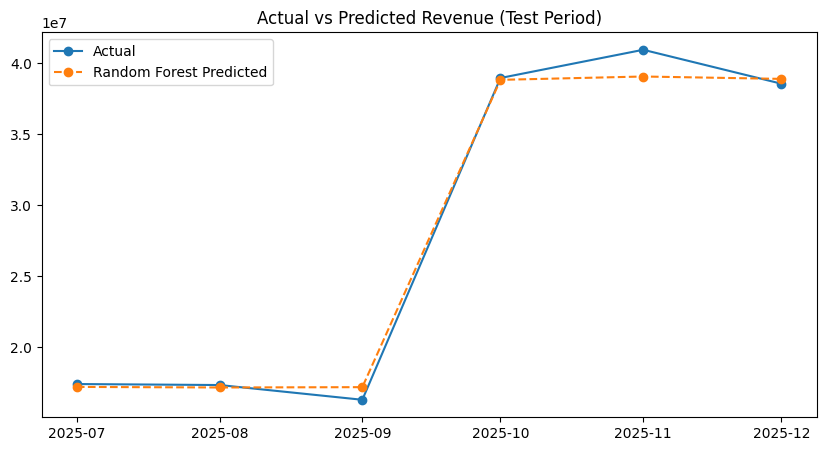

In [5]:
plt.figure(figsize=(10,5))
plt.plot(test["Date"], y_test.values, marker="o", label="Actual")
plt.plot(test["Date"], rf_preds, marker="o", linestyle="--", label="Random Forest Predicted")
plt.legend(); plt.title("Actual vs Predicted Revenue (Test Period)")
plt.show()

## 6. Forecast next 6 months

In [6]:
history = monthly.copy()
future_rows = []
for step in range(1, 7):
    next_date = history["Date"].max() + pd.DateOffset(months=1)
    row = {
        "month_index": history["month_index"].max() + 1,
        "month_of_year": next_date.month,
        "quarter": (next_date.month - 1)//3 + 1,
        "lag_1": history["Revenue"].iloc[-1],
        "lag_2": history["Revenue"].iloc[-2],
        "lag_3": history["Revenue"].iloc[-3],
    }
    pred = rf.predict(pd.DataFrame([row]))[0]
    future_rows.append({"Date": next_date, "Revenue": pred})
    history = pd.concat([history, pd.DataFrame([{**row, "Date": next_date, "Revenue": pred}])], ignore_index=True)

forecast_df = pd.DataFrame(future_rows)
forecast_df

,Date,Revenue
0,2026-01-01,1.788165e+07
1,2026-02-01,1.669146e+07
2,2026-03-01,1.666884e+07
3,2026-04-01,1.641742e+07
4,2026-05-01,1.672687e+07
5,2026-06-01,1.689285e+07


## 7. Plot full history + forecast

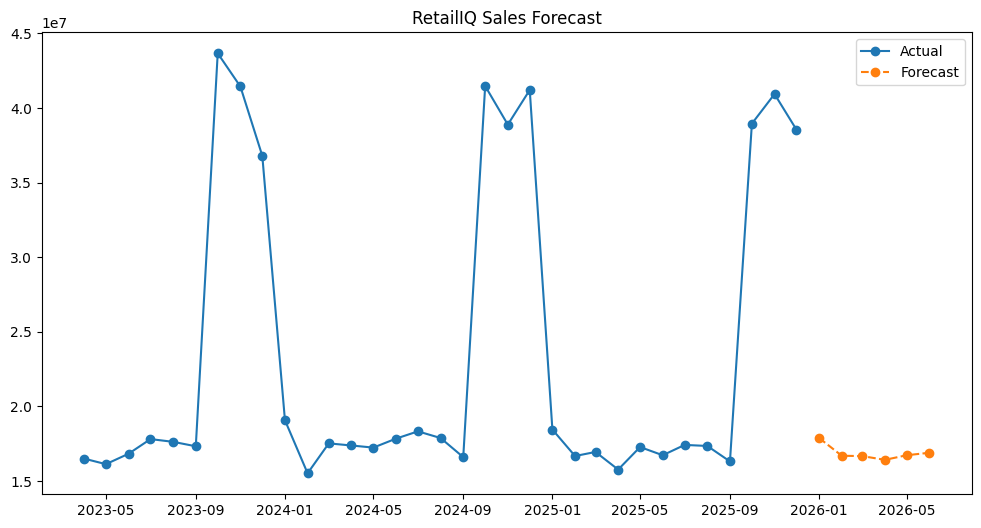

In [7]:
plt.figure(figsize=(12,6))
plt.plot(monthly["Date"], monthly["Revenue"], marker="o", label="Actual")
plt.plot(forecast_df["Date"], forecast_df["Revenue"], marker="o", linestyle="--", label="Forecast")
plt.legend(); plt.title("RetailIQ Sales Forecast")
plt.show()